<a href="https://colab.research.google.com/github/Eshitanagaria/Isro-Cloud-removal/blob/main/Isrohack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install earthengine-api geemap -q
import ee
import geemap
ee.Authenticate()
ee.Initialize(project='isrocloudproj')


In [ ]:
# Small tile near Guwahati(~5x5 km)
aoi = ee.Geometry.Rectangle([91.70, 26.10, 91.75, 26.15])

# Visualize to sanity-check the location
Map = geemap.Map()
Map.centerObject(aoi, 12)
Map.addLayer(aoi, {}, "AOI")
Map

Map(center=[26.125000372998418, 91.72499999999813], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2024-01-01', '2024-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .sort('CLOUDY_PIXEL_PERCENTAGE'))

print("Number of clear images found:", s2_collection.size().getInfo())

s2_image = s2_collection.first()
s2_bands = s2_image.select(['B4', 'B3', 'B2', 'B8'])
date_used = ee.Date(s2_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()
print("Date of selected image:", date_used)

Number of clear images found: 13
Date of selected image: 2024-02-10


In [ ]:
s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(aoi)
    .filterDate('2024-01-01', '2024-03-31')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))

print("Number of S1 images found:", s1_collection.size().getInfo())

s1_image = s1_collection.first()
s1_bands = s1_image.select(['VV', 'VH'])
s1_date = ee.Date(s1_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()
print("S1 date:", s1_date)

Number of S1 images found: 22
S1 date: 2024-01-01


In [ ]:
import os
os.makedirs('/content/data', exist_ok=True)

# Sentinel-2 export
geemap.ee_export_image(
    s2_bands,
    filename='/content/data/s2_tile.tif',
    scale=10,           # 10m resolution, matches S2's native res
    region=aoi,
    crs='EPSG:32646',   # UTM zone for NER, adjust if your AOI is in a different zone
    file_per_band=False
)

# Sentinel-1 export — same scale, region, CRS so pixel grids match
geemap.ee_export_image(
    s1_bands,
    filename='/content/data/s1_tile.tif',
    scale=10,
    region=aoi,
    crs='EPSG:32646',
    file_per_band=False
)

print("Done. Check /content/data/ for the two files.")

Generating URL ...
Please wait ...
Data downloaded to /content/data/s2_tile.tif
Generating URL ...
Please wait ...
Data downloaded to /content/data/s1_tile.tif
Done. Check /content/data/ for the two files.


S2 shape: (560, 506) CRS: EPSG:32646 bands: 4
S1 shape: (560, 506) CRS: EPSG:32646 bands: 2


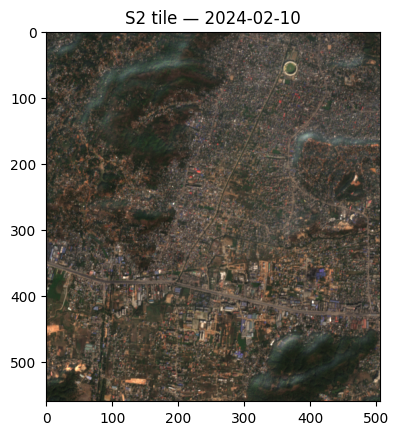

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open('/content/data/s2_tile.tif') as src:
    print("S2 shape:", src.shape, "CRS:", src.crs, "bands:", src.count)
    s2_arr = src.read()

with rasterio.open('/content/data/s1_tile.tif') as src:
    print("S1 shape:", src.shape, "CRS:", src.crs, "bands:", src.count)

# Quick visual check of S2 (RGB)
import numpy as np
rgb = np.dstack([s2_arr[0], s2_arr[1], s2_arr[2]])
rgb = np.clip(rgb / 3000, 0, 1)  # rough normalization for display
plt.imshow(rgb)
plt.title(f"S2 tile — {date_used}")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/isro_hackathon/data', exist_ok=True)
shutil.copy('/content/data/s2_tile.tif', '/content/drive/MyDrive/isro_hackathon/data/s2_tile.tif')
shutil.copy('/content/data/s1_tile.tif', '/content/drive/MyDrive/isro_hackathon/data/s1_tile.tif')
print("Saved to Drive.")

Mounted at /content/drive
Saved to Drive.


In [ ]:
import rasterio
import numpy as np

with rasterio.open('/content/drive/MyDrive/isro_hackathon/data/s2_tile.tif') as src:
    s2_full = src.read()  # shape: (4, 560, 506) -> bands, height, width

print("Full S2 array shape:", s2_full.shape)

PATCH_SIZE = 256
bands, H, W = s2_full.shape

patches = []
for top in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
    for left in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
        patch = s2_full[:, top:top+PATCH_SIZE, left:left+PATCH_SIZE]
        patches.append(patch)

print(f"Got {len(patches)} full {PATCH_SIZE}x{PATCH_SIZE} patches")

Full S2 array shape: (4, 560, 506)
Got 2 full 256x256 patches


In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_cloud_mask(size=256, num_blobs=None, seed=None):
    """Generates a soft, blob-shaped binary-ish mask simulating cloud cover."""
    rng = np.random.default_rng(seed)
    if num_blobs is None:
        num_blobs = rng.integers(1, 4)  # 1-3 cloud blobs per patch

    mask = np.zeros((size, size), dtype=np.float32)

    for _ in range(num_blobs):
        cx, cy = rng.integers(0, size, size=2)
        radius = rng.integers(size // 8, size // 3)

        yy, xx = np.ogrid[:size, :size]
        dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
        blob = np.clip(1 - dist / radius, 0, 1)
        mask = np.maximum(mask, blob)

    # Smooth edges
    mask = gaussian_filter(mask, sigma=size // 20)
    mask = np.clip(mask, 0, 1)
    return mask

In [ ]:
def apply_cloud(patch, mask, cloud_brightness=0.9):
    """
    patch: (bands, H, W) array, reflectance-like values
    mask: (H, W) array, 0 = clear, 1 = full cloud
    """
    patch_norm = patch.astype(np.float32)
    max_val = np.percentile(patch_norm, 99)  # rough normalization reference
    patch_scaled = np.clip(patch_norm / max_val, 0, 1)

    cloud_layer = np.ones_like(patch_scaled) * cloud_brightness
    mask_3d = mask[np.newaxis, :, :]  # broadcast across bands

    cloudy = patch_scaled * (1 - mask_3d) + cloud_layer * mask_3d
    return cloudy, patch_scaled  # cloudy version, clean normalized version

In [ ]:
import os

os.makedirs('/content/drive/MyDrive/isro_hackathon/data/synthetic/clean', exist_ok=True)
os.makedirs('/content/drive/MyDrive/isro_hackathon/data/synthetic/cloudy', exist_ok=True)
os.makedirs('/content/drive/MyDrive/isro_hackathon/data/synthetic/mask', exist_ok=True)

for i, patch in enumerate(patches):
    mask = generate_cloud_mask(size=PATCH_SIZE, seed=i)
    cloudy, clean_norm = apply_cloud(patch, mask)

    np.save(f'/content/drive/MyDrive/isro_hackathon/data/synthetic/clean/patch_{i:04d}.npy', clean_norm)
    np.save(f'/content/drive/MyDrive/isro_hackathon/data/synthetic/cloudy/patch_{i:04d}.npy', cloudy)
    np.save(f'/content/drive/MyDrive/isro_hackathon/data/synthetic/mask/patch_{i:04d}.npy', mask)

print(f"Saved {len(patches)} synthetic triples.")

Saved 2 synthetic triples.


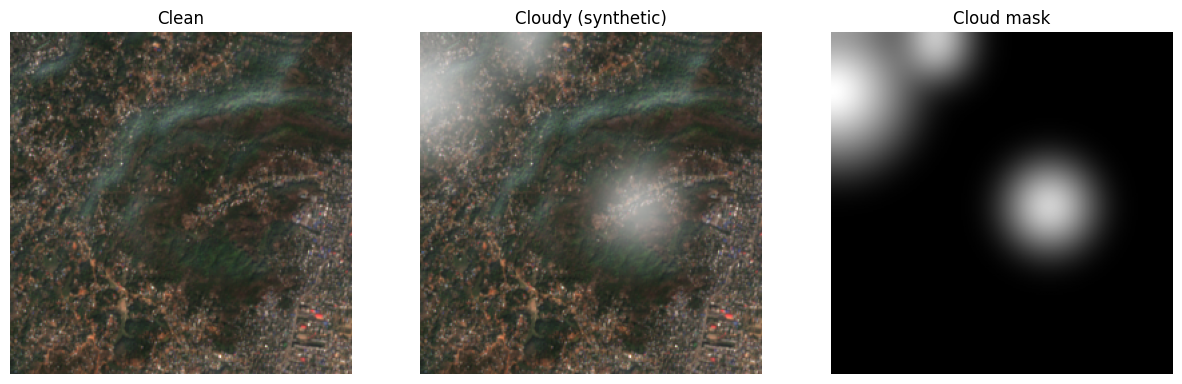

In [ ]:
import matplotlib.pyplot as plt

idx = 0  # change this to check different patches
clean = np.load(f'/content/drive/MyDrive/isro_hackathon/data/synthetic/clean/patch_{idx:04d}.npy')
cloudy = np.load(f'/content/drive/MyDrive/isro_hackathon/data/synthetic/cloudy/patch_{idx:04d}.npy')
mask = np.load(f'/content/drive/MyDrive/isro_hackathon/data/synthetic/mask/patch_{idx:04d}.npy')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.transpose(clean[:3], (1, 2, 0)))
axes[0].set_title("Clean")
axes[1].imshow(np.transpose(cloudy[:3], (1, 2, 0)))
axes[1].set_title("Cloudy (synthetic)")
axes[2].imshow(mask, cmap='gray')
axes[2].set_title("Cloud mask")
for ax in axes: ax.axis('off')
plt.show()

In [ ]:
import ee
import geemap
import rasterio
import numpy as np
import os

# Global patch counter so files don't overwrite across tiles
patch_counter = 0

def process_tile(aoi_coords, date_range, tile_name, crs='EPSG:32646', cloud_thresh=10):
    """
    aoi_coords: [west, south, east, north]
    date_range: (start_date, end_date) as strings 'YYYY-MM-DD'
    tile_name: string label for logging/debugging
    """
    global patch_counter

    aoi = ee.Geometry.Rectangle(aoi_coords)

    # --- Pull S2 ---
    s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(date_range[0], date_range[1])
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .sort('CLOUDY_PIXEL_PERCENTAGE'))

    n_s2 = s2_collection.size().getInfo()
    if n_s2 == 0:
        print(f"[{tile_name}] No clear S2 images found, skipping.")
        return 0

    s2_image = s2_collection.first()
    s2_bands = s2_image.select(['B4', 'B3', 'B2', 'B8'])
    used_date = ee.Date(s2_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()

    # --- Pull S1 (closest in time to the S2 date, +/- 30 days) ---
    s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(date_range[0], date_range[1])
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))

    n_s1 = s1_collection.size().getInfo()
    if n_s1 == 0:
        print(f"[{tile_name}] No S1 images found, skipping.")
        return 0

    s1_image = s1_collection.first()
    s1_bands = s1_image.select(['VV', 'VH'])

    # --- Export both ---
    s2_path = f'/content/data/{tile_name}_s2.tif'
    s1_path = f'/content/data/{tile_name}_s1.tif'

    geemap.ee_export_image(s2_bands, filename=s2_path, scale=10, region=aoi, crs=crs, file_per_band=False)
    geemap.ee_export_image(s1_bands, filename=s1_path, scale=10, region=aoi, crs=crs, file_per_band=False)

    # --- Load and check shapes match ---
    with rasterio.open(s2_path) as src:
        s2_arr = src.read()
    with rasterio.open(s1_path) as src:
        s1_arr = src.read()

    if s2_arr.shape[1:] != s1_arr.shape[1:]:
        print(f"[{tile_name}] WARNING: shape mismatch S2 {s2_arr.shape} vs S1 {s1_arr.shape}, skipping.")
        return 0

    print(f"[{tile_name}] {used_date} | S2 {s2_arr.shape} | S1 {s1_arr.shape}")

    # --- Slice into patches ---
    bands, H, W = s2_arr.shape
    saved_this_tile = 0

    base = '/content/drive/MyDrive/isro_hackathon/data/synthetic'
    for sub in ['clean', 'cloudy', 'mask', 'sar']:
        os.makedirs(f'{base}/{sub}', exist_ok=True)

    for top in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
        for left in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
            s2_patch = s2_arr[:, top:top+PATCH_SIZE, left:left+PATCH_SIZE]
            s1_patch = s1_arr[:, top:top+PATCH_SIZE, left:left+PATCH_SIZE]

            mask = generate_cloud_mask(size=PATCH_SIZE, seed=patch_counter)
            cloudy, clean_norm = apply_cloud(s2_patch, mask)

            idx_str = f'{patch_counter:04d}'
            np.save(f'{base}/clean/patch_{idx_str}.npy', clean_norm)
            np.save(f'{base}/cloudy/patch_{idx_str}.npy', cloudy)
            np.save(f'{base}/mask/patch_{idx_str}.npy', mask)
            np.save(f'{base}/sar/patch_{idx_str}.npy', s1_patch.astype(np.float32))

            patch_counter += 1
            saved_this_tile += 1

    print(f"[{tile_name}] Saved {saved_this_tile} patches. Total so far: {patch_counter}")
    return saved_this_tile

In [ ]:
# (west, south, east, north) boxes around different NER cities

tiles_to_pull = [
    {"aoi_coords": [91.70, 26.10, 91.78, 26.18], "tile_name": "guwahati_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [91.85, 25.55, 91.93, 25.63], "tile_name": "shillong_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [93.93, 27.06, 94.01, 27.14], "tile_name": "itanagar_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [93.92, 24.78, 94.00, 24.86], "tile_name": "imphal_1", "date_range": ("2023-11-01", "2024-04-30")},
]

total_patches = 0
for t in tiles_to_pull:
    total_patches += process_tile(**t)

print(f"\nDONE. Total patches across all tiles: {total_patches}")

Generating URL ...
Please wait ...
Data downloaded to /content/data/guwahati_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/guwahati_1_s1.tif
[guwahati_1] 2024-02-10 | S2 (4, 895, 809) | S1 (2, 895, 809)
[guwahati_1] Saved 9 patches. Total so far: 9
Generating URL ...
Please wait ...
Data downloaded to /content/data/shillong_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/shillong_1_s1.tif
[shillong_1] 2024-02-10 | S2 (4, 894, 811) | S1 (2, 894, 811)
[shillong_1] Saved 9 patches. Total so far: 18
Generating URL ...
Please wait ...
Data downloaded to /content/data/itanagar_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/itanagar_1_s1.tif
[itanagar_1] 2023-11-14 | S2 (4, 893, 801) | S1 (2, 893, 801)
[itanagar_1] Saved 9 patches. Total so far: 27
Generating URL ...
Please wait ...
Data downloaded to /content/data/imphal_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/imphal_1_s1.tif
[imphal_1] 2024-03-08 | S2 (4, 892, 816) | S1 (2, 892, 816)
[imphal_1] Saved 9 patches. Total so far: 36

DONE. Total patches across all tiles: 36


In [ ]:
more_tiles_to_pull = [
    # More dates for cities you already have (different season = different look)
    {"aoi_coords": [91.70, 26.10, 91.78, 26.18], "tile_name": "guwahati_2", "date_range": ("2024-05-01", "2024-10-31")},
    {"aoi_coords": [91.85, 25.55, 91.93, 25.63], "tile_name": "shillong_2", "date_range": ("2024-05-01", "2024-10-31")},
    {"aoi_coords": [93.93, 27.06, 94.01, 27.14], "tile_name": "itanagar_2", "date_range": ("2024-05-01", "2024-10-31")},
    {"aoi_coords": [93.92, 24.78, 94.00, 24.86], "tile_name": "imphal_2", "date_range": ("2024-05-01", "2024-10-31")},

    # New NER locations
    {"aoi_coords": [91.27, 26.13, 91.35, 26.21], "tile_name": "nalbari_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [92.79, 26.58, 92.87, 26.66], "tile_name": "tezpur_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [89.27, 26.49, 89.35, 26.57], "tile_name": "cooch_adjacent_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [92.94, 24.32, 93.02, 24.40], "tile_name": "aizawl_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [91.36, 23.84, 91.44, 23.92], "tile_name": "agartala_1", "date_range": ("2023-11-01", "2024-04-30")},
    {"aoi_coords": [91.36, 25.57, 91.44, 25.65], "tile_name": "nongpoh_1", "date_range": ("2023-11-01", "2024-04-30")},
]

total_new_patches = 0
for t in more_tiles_to_pull:
    total_new_patches += process_tile(**t)

print(f"\nDONE THIS BATCH. New patches: {total_new_patches}")
print(f"GRAND TOTAL across all tiles so far: {patch_counter}")

Generating URL ...
Please wait ...
Data downloaded to /content/data/guwahati_2_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/guwahati_2_s1.tif
[guwahati_2] 2024-10-22 | S2 (4, 895, 809) | S1 (2, 895, 809)
[guwahati_2] Saved 9 patches. Total so far: 45
Generating URL ...
Please wait ...
Data downloaded to /content/data/shillong_2_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/shillong_2_s1.tif
[shillong_2] 2024-10-22 | S2 (4, 894, 811) | S1 (2, 894, 811)
[shillong_2] Saved 9 patches. Total so far: 54
Generating URL ...
Please wait ...
Data downloaded to /content/data/itanagar_2_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/itanagar_2_s1.tif
[itanagar_2] 2024-05-22 | S2 (4, 893, 801) | S1 (2, 893, 801)
[itanagar_2] Saved 9 patches. Total so far: 63
Generating URL ...
Please wait ...
Data downloaded to /content/data/imphal_2_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/imphal_2_s1.tif
[imphal_2] 2024-09-19 | S2 (4, 892, 816) | S1 (2, 892, 816)
[imphal_2] Saved 9 patches. Total so far: 72
Generating URL ...
Please wait ...
Data downloaded to /content/data/nalbari_1_s2.tif
Generating URL ...
Please wait ...


...

Data downloaded to /content/data/tezpur_1_s1.tif
[tezpur_1] 2024-02-10 | S2 (4, 888, 799) | S1 (2, 888, 799)
[tezpur_1] Saved 9 patches. Total so far: 90
Generating URL ...
Please wait ...
Data downloaded to /content/data/cooch_adjacent_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/cooch_adjacent_1_s1.tif
[cooch_adjacent_1] 2023-12-30 | S2 (4, 911, 824) | S1 (2, 911, 824)
[cooch_adjacent_1] Saved 9 patches. Total so far: 99
Generating URL ...
Please wait ...
Data downloaded to /content/data/aizawl_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/aizawl_1_s1.tif
[aizawl_1] 2024-03-03 | S2 (4, 887, 812) | S1 (2, 887, 812)
[aizawl_1] Saved 9 patches. Total so far: 108
Generating URL ...
Please wait ...
Data downloaded to /content/data/agartala_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/agartala_1_s1.tif
[agartala_1] 2024-02-10 | S2 (4, 896, 825) | S1 (2, 896, 825)
[agartala_1] Saved 9 patches. Total so far: 117
Generating URL ...
Please wait ...
Data downloaded to /content/data/nongpoh_1_s2.tif
Generating URL ...
Please wait ...


Data downloaded to /content/data/nongpoh_1_s1.tif
[nongpoh_1] 2024-02-10 | S2 (4, 897, 815) | S1 (2, 897, 815)
[nongpoh_1] Saved 9 patches. Total so far: 126

DONE THIS BATCH. New patches: 90
GRAND TOTAL across all tiles so far: 126


In [ ]:
!pip install scikit-image -q

import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def spectral_angle_mapper(pred, target, eps=1e-8):
    """
    Computes mean Spectral Angle Mapper (SAM) in degrees between two
    multi-band images. Lower = more spectrally similar.
    pred, target: (bands, H, W) arrays
    """
    pred_flat = pred.reshape(pred.shape[0], -1).T   # (pixels, bands)
    target_flat = target.reshape(target.shape[0], -1).T

    dot = np.sum(pred_flat * target_flat, axis=1)
    pred_norm = np.linalg.norm(pred_flat, axis=1)
    target_norm = np.linalg.norm(target_flat, axis=1)

    cos_angle = dot / (pred_norm * target_norm + eps)
    cos_angle = np.clip(cos_angle, -1, 1)
    angles = np.arccos(cos_angle)  # radians per pixel

    mean_angle_deg = np.degrees(np.mean(angles))
    return mean_angle_deg

In [ ]:
def evaluate(pred, target):
    """
    pred, target: (bands, H, W) numpy arrays, values expected in [0, 1]
    Returns a dict of SSIM, PSNR, SAM.
    """
    # SSIM/PSNR need (H, W, bands) format and a data_range
    pred_hwc = np.transpose(pred, (1, 2, 0))
    target_hwc = np.transpose(target, (1, 2, 0))

    ssim_val = ssim(target_hwc, pred_hwc, data_range=1.0, channel_axis=2)
    psnr_val = psnr(target_hwc, pred_hwc, data_range=1.0)
    sam_val = spectral_angle_mapper(pred, target)

    return {
        "SSIM": round(float(ssim_val), 4),
        "PSNR_dB": round(float(psnr_val), 2),
        "SAM_deg": round(float(sam_val), 2)
    }

In [ ]:
# TESTING
clean = np.load('/content/drive/MyDrive/isro_hackathon/data/synthetic/clean/patch_0000.npy')
cloudy = np.load('/content/drive/MyDrive/isro_hackathon/data/synthetic/cloudy/patch_0000.npy')

print("Clean vs Clean (sanity check, should be near-perfect):")
print(evaluate(clean, clean))

print("\nClean vs Cloudy (should be worse):")
print(evaluate(cloudy, clean))

Clean vs Clean (sanity check, should be near-perfect):
{'SSIM': 1.0, 'PSNR_dB': inf, 'SAM_deg': 0.01}

Clean vs Cloudy (should be worse):
{'SSIM': 0.9089, 'PSNR_dB': 17.37, 'SAM_deg': 3.76}


In [ ]:
def compute_indices(patch):
    """
    patch: (4, H, W) array in band order R, G, B, NIR (bands 0,1,2,3)
    Returns (3, H, W) array of [NDVI, NDWI, Band_ratio]
    """
    R   = patch[0].astype(np.float32)
    G   = patch[1].astype(np.float32)
    NIR = patch[3].astype(np.float32)
    eps = 1e-8

    NDVI = (NIR - R) / (NIR + R + eps)      # vegetation: high = green
    NDWI = (G - NIR) / (G + NIR + eps)      # water: high = water
    BAND_RATIO = R / (NIR + eps)            # built-up proxy

    return np.stack([NDVI, NDWI, BAND_RATIO], axis=0)  # (3, H, W)

In [ ]:
def auto_label(indices):
    """
    indices: (3, H, W) -> NDVI, NDWI, band_ratio
    Returns (H, W) label map:
        0 = vegetation  (high NDVI)
        1 = water       (high NDWI)
        2 = built-up    (low NDVI, low NDWI)
    """
    NDVI = indices[0]
    NDWI = indices[1]

    labels = np.full(NDVI.shape, 2, dtype=np.int32)  # default: built-up
    labels[NDVI > 0.3] = 0                            # vegetation
    labels[NDWI > 0.1] = 1                            # water (overrides veg if both high)

    return labels

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def build_pixel_dataset(patch_indices_list, label_list):
    """
    Flattens (3, H, W) index maps and (H, W) label maps into
    sklearn-ready X (pixels, 3) and y (pixels,) arrays.
    """
    X_all, y_all = [], []
    for indices, labels in zip(patch_indices_list, label_list):
        X = indices.reshape(3, -1).T   # (H*W, 3)
        y = labels.reshape(-1)          # (H*W,)
        X_all.append(X)
        y_all.append(y)
    return np.vstack(X_all), np.concatenate(y_all)

# Load all patches and compute indices for clean and cloudy versions
base = '/content/drive/MyDrive/isro_hackathon/data/synthetic'
n_patches = 126  # your total

clean_indices_list, cloudy_indices_list, label_list = [], [], []

for i in range(n_patches):
    idx_str = f'{i:04d}'
    clean  = np.load(f'{base}/clean/patch_{idx_str}.npy')
    cloudy = np.load(f'{base}/cloudy/patch_{idx_str}.npy')

    clean_idx  = compute_indices(clean)
    cloudy_idx = compute_indices(cloudy)
    labels     = auto_label(clean_idx)   # ground truth labels from clean

    clean_indices_list.append(clean_idx)
    cloudy_indices_list.append(cloudy_idx)
    label_list.append(labels)

print(f"Loaded {n_patches} patches.")

# Build datasets
X_clean,  y_clean  = build_pixel_dataset(clean_indices_list,  label_list)
X_cloudy, y_cloudy = build_pixel_dataset(cloudy_indices_list, label_list)

print(f"Total pixels: {X_clean.shape[0]:,}")

Loaded 126 patches.
Total pixels: 8,257,536


In [ ]:

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Get matching cloudy test set
_, X_te_cloudy, _, _ = train_test_split(
    X_cloudy, y_cloudy, test_size=0.2, random_state=42
)

# Train on clean data
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
print("Training done.")

# Evaluate on clean test pixels
acc_clean  = accuracy_score(y_te, rf.predict(X_te))

# Evaluate on same pixels but from cloudy version
acc_cloudy = accuracy_score(y_te, rf.predict(X_te_cloudy))

print("\n========= LULC VALIDATION RESULTS =========")
print(f"Accuracy on CLEAN  pixels : {acc_clean*100:.2f}%")
print(f"Accuracy on CLOUDY pixels : {acc_cloudy*100:.2f}%")
print(f"Accuracy DELTA            : {(acc_clean - acc_cloudy)*100:.2f}% degradation from cloud")
print("=============================================")
print("\nThis delta is what cloud removal aims to recover.")

Training done.

========= LULC VALIDATION RESULTS =========
Accuracy on CLEAN  pixels : 100.00%
Accuracy on CLOUDY pixels : 91.65%
Accuracy DELTA            : 8.35% degradation from cloud

This delta is what cloud removal aims to recover.


In [ ]:
import pandas as pd

results_table = pd.DataFrame({
    'Source': ['Clean (ground truth)', 'Cloudy (degraded)'],
    'LULC Accuracy (%)': [
        round(acc_clean * 100, 2),
        round(acc_cloudy * 100, 2),

    ]
})

print(results_table.to_string(index=False))

# Save to Drive
results_table.to_csv('/content/drive/MyDrive/isro_hackathon/lulc_results.csv', index=False)
print("\nSaved to Drive.")

              Source  LULC Accuracy (%)
Clean (ground truth)             100.00
   Cloudy (degraded)              91.65

Saved to Drive.
